In [1]:
import analysis_fce as af

In [2]:
path = "C:/Users/kryst/OneDrive/Documents/Škola/Konference/MME 2026/results/raw"
save_path = "C:/Users/kryst/OneDrive/Documents/Škola/Konference/MME 2026/results/analysis/"

In [3]:
outlier_scenarios = {
    "1": ["50"],
    "2": ["50"],
    "3": ["50"],
    "4": ["50"],
    "5": ["50"],
    "6": ["50"],
    "7": ["50"],
    "8": ["50"],
    "9": ["50"],
    "10": ["50"],
    "11": ["50"],
    "12": ["50"]
}

In [4]:
base_coeff = {
    "X1": 0.8,
    "X2": -0.6,
    "X3": 0.6,
    "X4": -0.9,
}

base_with_lag = {**base_coeff, "X5": 0.0}  # X5 = target_lag
base_with_noncausal = {**base_coeff, "X5": 0.0}  # X5 = noncausal predictor
base_with_nonlinear_pred = {**base_coeff, "X5": -0.1}  # X5 = X4^2

nonlinear_coeff = {
    "X1": 0.0,
    "X2": 0.0,
    "X3": 0.1,
    "X4": -0.5,
}

nonlinear_all = {
    **nonlinear_coeff,
    "X5": 0.0,   # noncausal predictor
    "X6": -0.1,  # X4^2
    "X7": 0.0,   # target_lag
}

true_coeff_groups = {
    "1": base_coeff.copy(),            # Scenarios 1-3
    "2": base_coeff.copy(),            # Scenarios 4-6 (corr_m only)
    "3": base_with_lag.copy(),         # Scenarios 7-9 (auto_corr -> target_lag)
    "4": base_coeff.copy(),            # Scenarios 10-12 (noise_norm)
    "5": base_coeff.copy(),            # Scenarios 13-15 (omitted_var)
    "6": base_coeff.copy(),            # Scenarios 16-18 (endogeneity)
    "7": base_coeff.copy(),            # Scenarios 19-21 (heteroskedasticity)
    "8": base_coeff.copy(),            # Scenarios 22-24 (nonnormal_features)
    "9": base_with_nonlinear_pred.copy(),  # Scenarios 25-27 (nonlinear_predictor)
    "10": nonlinear_coeff.copy(),      # Scenarios 28-30 (nonlinear target)
    "11": base_with_noncausal.copy(),  # Scenarios 31-33 (noncausal_predictor)
    "12": nonlinear_all.copy(),        # Scenarios 34-36 (all violations)
}

In [4]:
df_coef = af.load_data(path, "coeff", 6)
df_std = af.load_data(path, "std_err", 6)

In [7]:
df_coef_clean, df_std_clean = af.remove_outliers(df_coef, outlier_scenarios, df_std)

Scenario: 1, N: 50 - Outliers: 58, NaNs: 0
Scenario: 2, N: 50 - Outliers: 67, NaNs: 1
Scenario: 3, N: 50 - Outliers: 0, NaNs: 0
Scenario: 4, N: 50 - Outliers: 0, NaNs: 0
Scenario: 5, N: 50 - Outliers: 0, NaNs: 0
Scenario: 6, N: 50 - Outliers: 0, NaNs: 0
Scenario: 7, N: 50 - Outliers: 0, NaNs: 0
Scenario: 8, N: 50 - Outliers: 0, NaNs: 0


In [8]:
df_coef_clean.shape, df_std_clean.shape

((2875, 6), (2875, 7))

In [9]:
coef_bias = af.calculate_coeff_bias(df_coef_clean, true_coeff_groups)

In [11]:
coef_bias_latex = af.bias_to_latex(coef_bias)

In [12]:
print(coef_bias_latex)

\begin{table}
\caption{Bias and RMSE of the estimated coefficients compared to the true coefficients for each scenario and N.}
\begin{tabular}{llrrrrrrrr}
\toprule
 & Coefficient & \multicolumn{2}{r}{X1} & \multicolumn{2}{r}{X2} & \multicolumn{2}{r}{X3} & \multicolumn{2}{r}{X4} \\
 &  & Bias & RMSE & Bias & RMSE & Bias & RMSE & Bias & RMSE \\
Scenario & N &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{1} & 50 & 0.197 & 0.624 & -0.127 & 0.504 & 0.105 & 0.540 & -0.130 & 0.546 \\
 & 500 & 0.012 & 0.132 & -0.012 & 0.140 & 0.028 & 0.140 & -0.023 & 0.148 \\
 & 5000 & 0.003 & 0.044 & -0.001 & 0.041 & 0.002 & 0.044 & -0.001 & 0.044 \\
\cline{1-10}
\multirow[t]{3}{*}{2} & 50 & 0.175 & 0.746 & -0.066 & 0.735 & 0.044 & 0.629 & -0.216 & 0.770 \\
 & 500 & 0.025 & 0.198 & -0.030 & 0.198 & 0.010 & 0.187 & -0.008 & 0.216 \\
 & 5000 & -0.001 & 0.056 & -0.000 & 0.060 & 0.000 & 0.054 & -0.001 & 0.062 \\
\cline{1-10}
\bottomrule
\end{tabular}
\end{table}



In [3]:
df_ml = af.load_data(path, "metrics_all", 36)

In [4]:
# fix model name "Náhodné lesy" to "RF"
df_ml["Model"] = df_ml["Model"].replace("Náhodné lesy", "RF")

In [6]:
df_ml_res = af.calculate_ml_metric(df_ml, "Gini", "median")

In [6]:
caption = "Median Gini coefficient across scenarios and models."
print(af.ml_metric_to_latex(df_ml_res, caption))

\begin{table}
\caption{Median Gini coefficient across scenarios and models.}
\begin{tabular}{llrrrrrr}
\toprule
 & Model & GNB & LR & LR (WOE) & NN & RF & XGBoost \\
Scenario & N &  &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{1} & 50 & 0.500 & 0.583 & 0.333 & 0.417 & 0.458 & 0.360 \\
 & 500 & 0.606 & 0.619 & 0.542 & 0.588 & 0.550 & 0.532 \\
 & 5000 & 0.619 & 0.620 & 0.599 & 0.615 & 0.594 & 0.602 \\
\cline{1-8}
\multirow[t]{3}{*}{10} & 50 & 0.417 & 0.333 & 0.286 & 0.238 & 0.333 & 0.333 \\
 & 500 & 0.469 & 0.353 & 0.447 & 0.438 & 0.473 & 0.439 \\
 & 5000 & 0.487 & 0.367 & 0.512 & 0.524 & 0.515 & 0.527 \\
\cline{1-8}
\multirow[t]{3}{*}{11} & 50 & 0.554 & 0.583 & 0.333 & 0.440 & 0.500 & 0.440 \\
 & 500 & 0.599 & 0.638 & 0.566 & 0.613 & 0.576 & 0.557 \\
 & 5000 & 0.601 & 0.636 & 0.614 & 0.629 & 0.613 & 0.620 \\
\cline{1-8}
\multirow[t]{3}{*}{12} & 50 & 0.429 & 0.440 & 0.238 & 0.250 & 0.333 & 0.333 \\
 & 500 & 0.532 & 0.546 & 0.511 & 0.529 & 0.537 & 0.520 \\
 & 5000 & 0.553 & 0.564 & 0.595

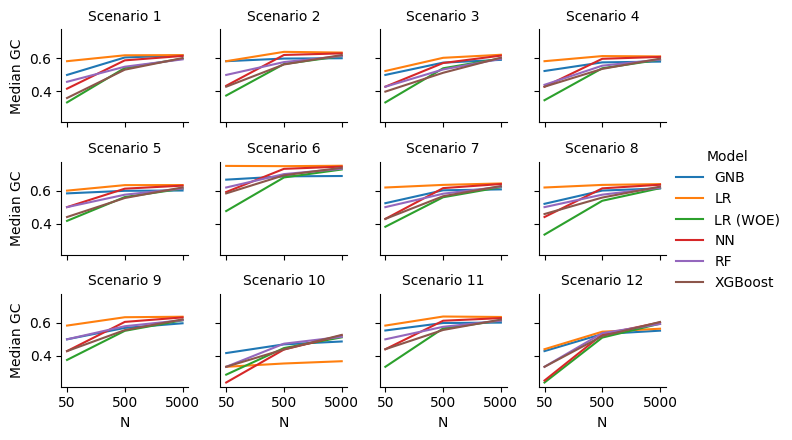

In [7]:
af.plot_ml_metric(df_ml_res, "Gini", None, "Median GC", save_path + "gini_median.pdf")

In [8]:
df_ml_res = af.calculate_ml_metric(df_ml, "Gini", "percent_best")

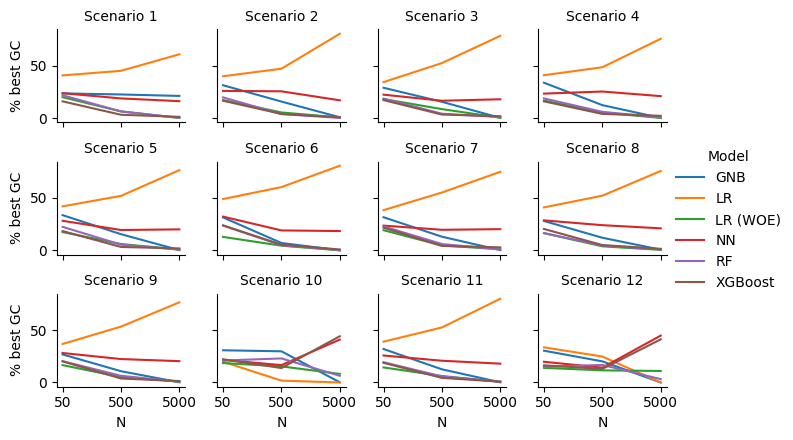

In [9]:
af.plot_ml_metric(df_ml_res, "Gini", None, "% best GC", save_path + "gini_percent_best.pdf")

In [10]:
df_ml_res = af.calculate_ml_metric(df_ml, "Gini", "average_rank")

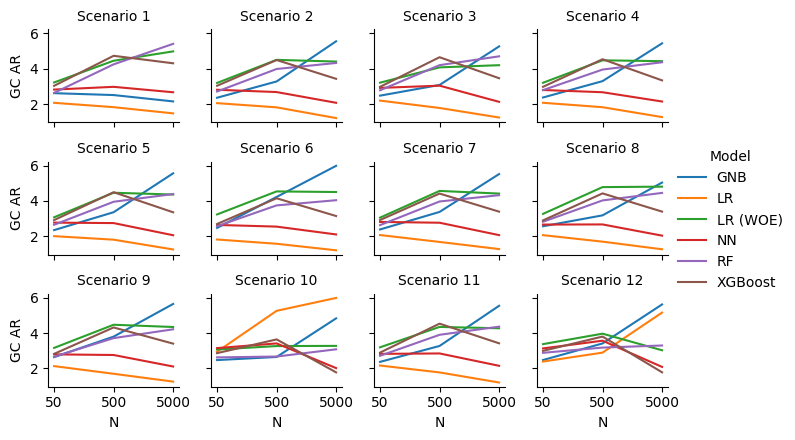

In [12]:
af.plot_ml_metric(df_ml_res, "Gini", None, "GC AR", save_path + "gini_average_rank.pdf")

In [5]:
friedman_df = af.calculate_friedman_test(df_ml, "Gini")
friedman_df

C:\data_projects\simulation_conference\analysis_fce\__init__.py:290: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset.loc[subset["Model"] == m, "Iteration"] = range(n_iter)
C:\data_projects\simulation_conference\analysis_fce\__init__.py:290: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset.loc[subset["Model"] == m, "Iteration"] = range(n_iter)
C:\data_projects\simulation_conference\analysis_fce\__init__.py:290: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

,Scenario,N,p-value,statistic
0,1,50,3.868767e-39,190.019835
1,2,50,6.239350e-49,235.756575
2,3,50,1.461581e-31,154.511950
3,4,50,1.268305e-45,220.320915
4,5,50,1.224042e-43,211.053896
5,6,50,3.089456e-62,297.724377
6,7,50,1.044750e-35,173.955382
7,8,50,7.514756e-44,212.043547
8,9,50,3.761260e-31,152.584304
9,10,50,1.493628e-15,78.802821


In [6]:
print(af.friedman_to_latex(friedman_df, "Friedman test p-values based on Gini coefficient."))

N                   50            500  5000
Scenario                                   
1         3.868767e-39  9.069292e-221   0.0
2         6.239350e-49  5.719831e-181   0.0
3         1.461581e-31  2.727160e-170   0.0
4         1.268305e-45  7.739606e-181   0.0
5         1.224042e-43  1.115341e-172   0.0
6         3.089456e-62  1.361225e-210   0.0
7         1.044750e-35  3.610957e-189   0.0
8         7.514756e-44  1.528212e-213   0.0
9         3.761260e-31  5.722132e-173   0.0
10        1.493628e-15  1.750637e-141   0.0
11        1.243720e-39  2.442806e-170   0.0
12        8.084755e-35   2.012567e-23   0.0
\begin{table}
\caption{Friedman test p-values based on Gini coefficient.}
\begin{tabular}{lrrr}
\toprule
N & 50 & 500 & 5000 \\
Scenario &  &  &  \\
\midrule
1 & 0.000 & 0.000 & 0.000 \\
2 & 0.000 & 0.000 & 0.000 \\
3 & 0.000 & 0.000 & 0.000 \\
4 & 0.000 & 0.000 & 0.000 \\
5 & 0.000 & 0.000 & 0.000 \\
6 & 0.000 & 0.000 & 0.000 \\
7 & 0.000 & 0.000 & 0.000 \\
8 & 0.000 & 0.000 & 0.0